In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

2025-04-11 01:03:38.146088: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744329818.164344   46179 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744329818.170039   46179 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744329818.184979   46179 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744329818.185003   46179 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744329818.185005   46179 computation_placer.cc:177] computation placer alr

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
x_train = pd.read_csv('x_train_not_standard.csv', index_col=0)
y_train = pd.read_csv('y_train_not_standard.csv', index_col=0)
x_test = pd.read_csv('x_test_not_standard.csv', index_col=0)
y_test = pd.read_csv('y_test_not_standard.csv', index_col=0)


In [4]:
print("Training features shape:", x_train.shape)
print("Training target shape:", y_train.shape)
print("Test features shape:", x_test.shape)
print("Test target shape:", y_test.shape)

Training features shape: (162, 67)
Training target shape: (162, 1)
Test features shape: (39, 67)
Test target shape: (39, 1)


In [5]:
print("\nMissing values in training data:", x_train.isnull().sum().sum())
print("Missing values in test data:", x_test.isnull().sum().sum())


Missing values in training data: 0
Missing values in test data: 0


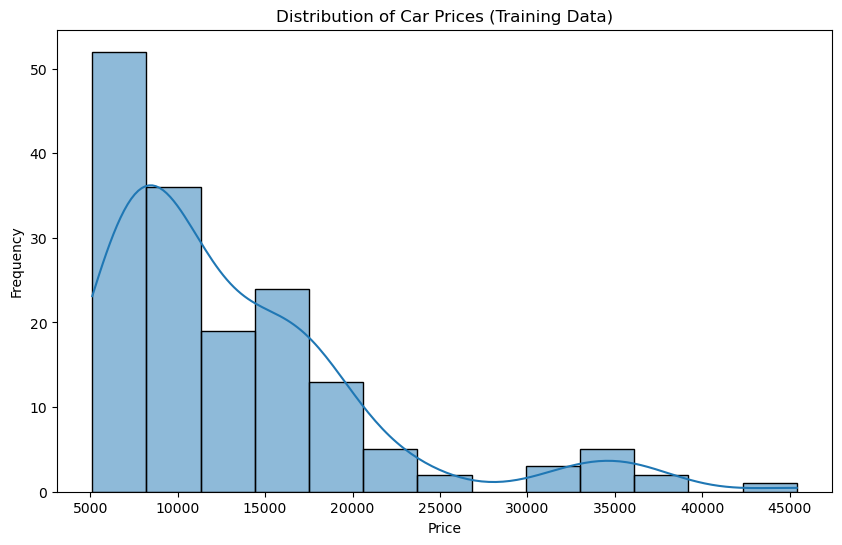

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(y_train['price'], kde=True)
plt.title('Distribution of Car Prices (Training Data)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [8]:
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

In [9]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-04-11 01:03:47.090957: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 1.0785 - mae: 0.8105 - val_loss: 0.8011 - val_mae: 0.5832
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4283 - mae: 0.4884 - val_loss: 0.5022 - val_mae: 0.4523
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3204 - mae: 0.4214 - val_loss: 0.3603 - val_mae: 0.3980
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3527 - mae: 0.4642 - val_loss: 0.2955 - val_mae: 0.3805
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2242 - mae: 0.3736 - val_loss: 0.2816 - val_mae: 0.3722
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2473 - mae: 0.3834 - val_loss: 0.2771 - val_mae: 0.3582
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1822 - mae: 0.3457 - val_loss: 0.2523 - val_mae: 0.3216
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1829 - mae: 0.3106 - val_loss: 0.2451 - val_mae: 0.3086
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1973 - mae: 

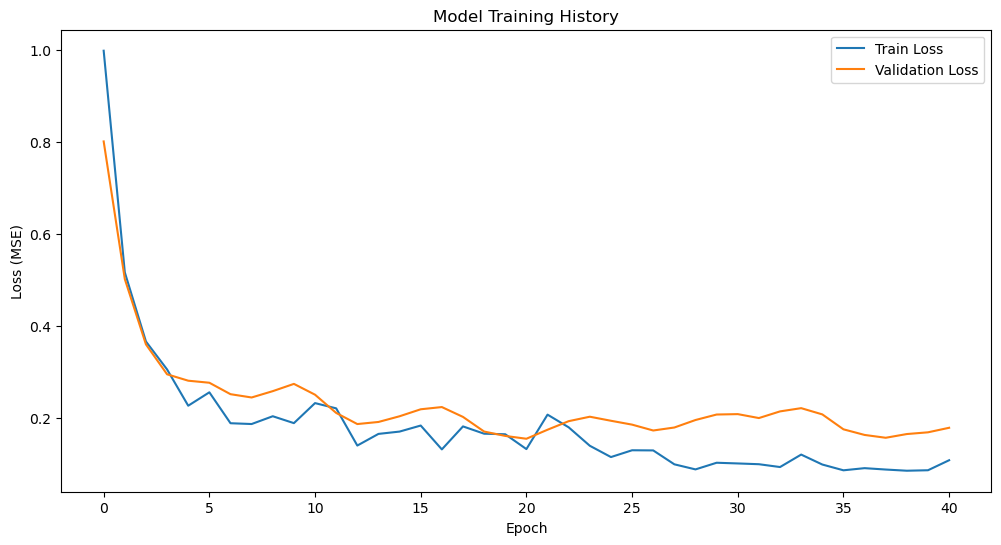

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [12]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Test MSE: 0.2221
Test MAE: 0.3092


In [13]:
y_pred_scaled = model.predict(X_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test_scaled)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [14]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print(f"\nRMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")


RMSE: 3595.67
MAE: 2358.76
R² Score: 0.8423


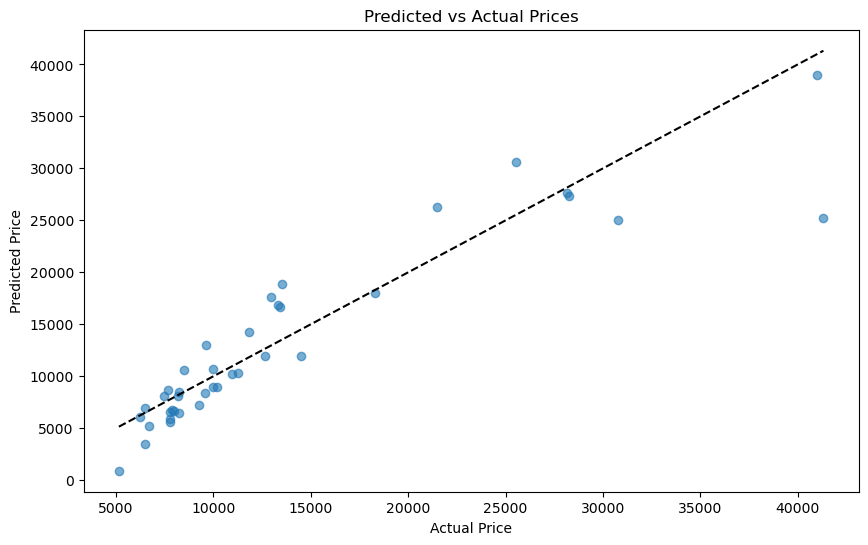

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_actual, y_pred, alpha=0.6)
plt.plot([min(y_test_actual), max(y_test_actual)], [min(y_test_actual), max(y_test_actual)], 'k--')
plt.title('Predicted vs Actual Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()


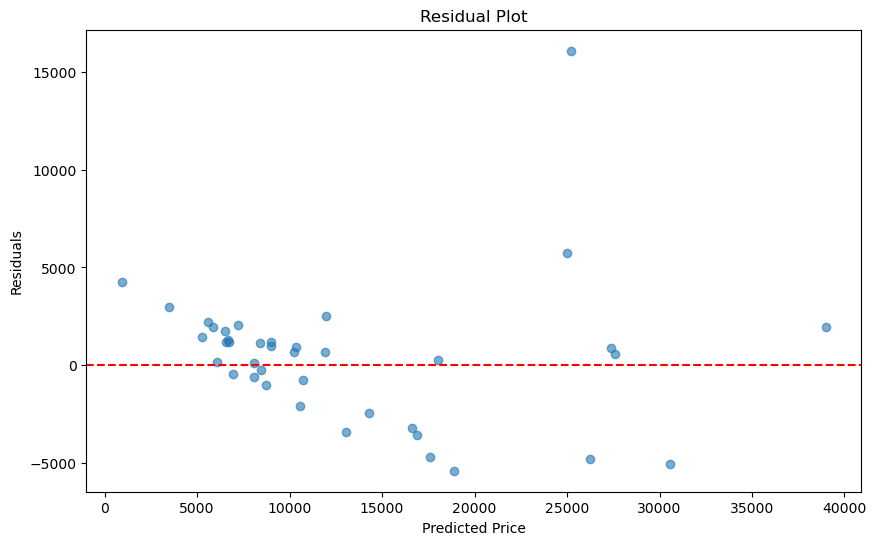

In [16]:
residuals = y_test_actual - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.show()